## Análisis del Método de Runge-Kutta 2 con Problemas de Caída Libre, Oscilador Armónico y Decaimiento Nuclear

Resolviendo caída libre...
Resolviendo oscilador armónico...
Resolviendo decaimiento nuclear...


/tmp/ipykernel_87963/2146794110.py:35: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  y_next = fsolve(equation, self.y_implicit[:, i])


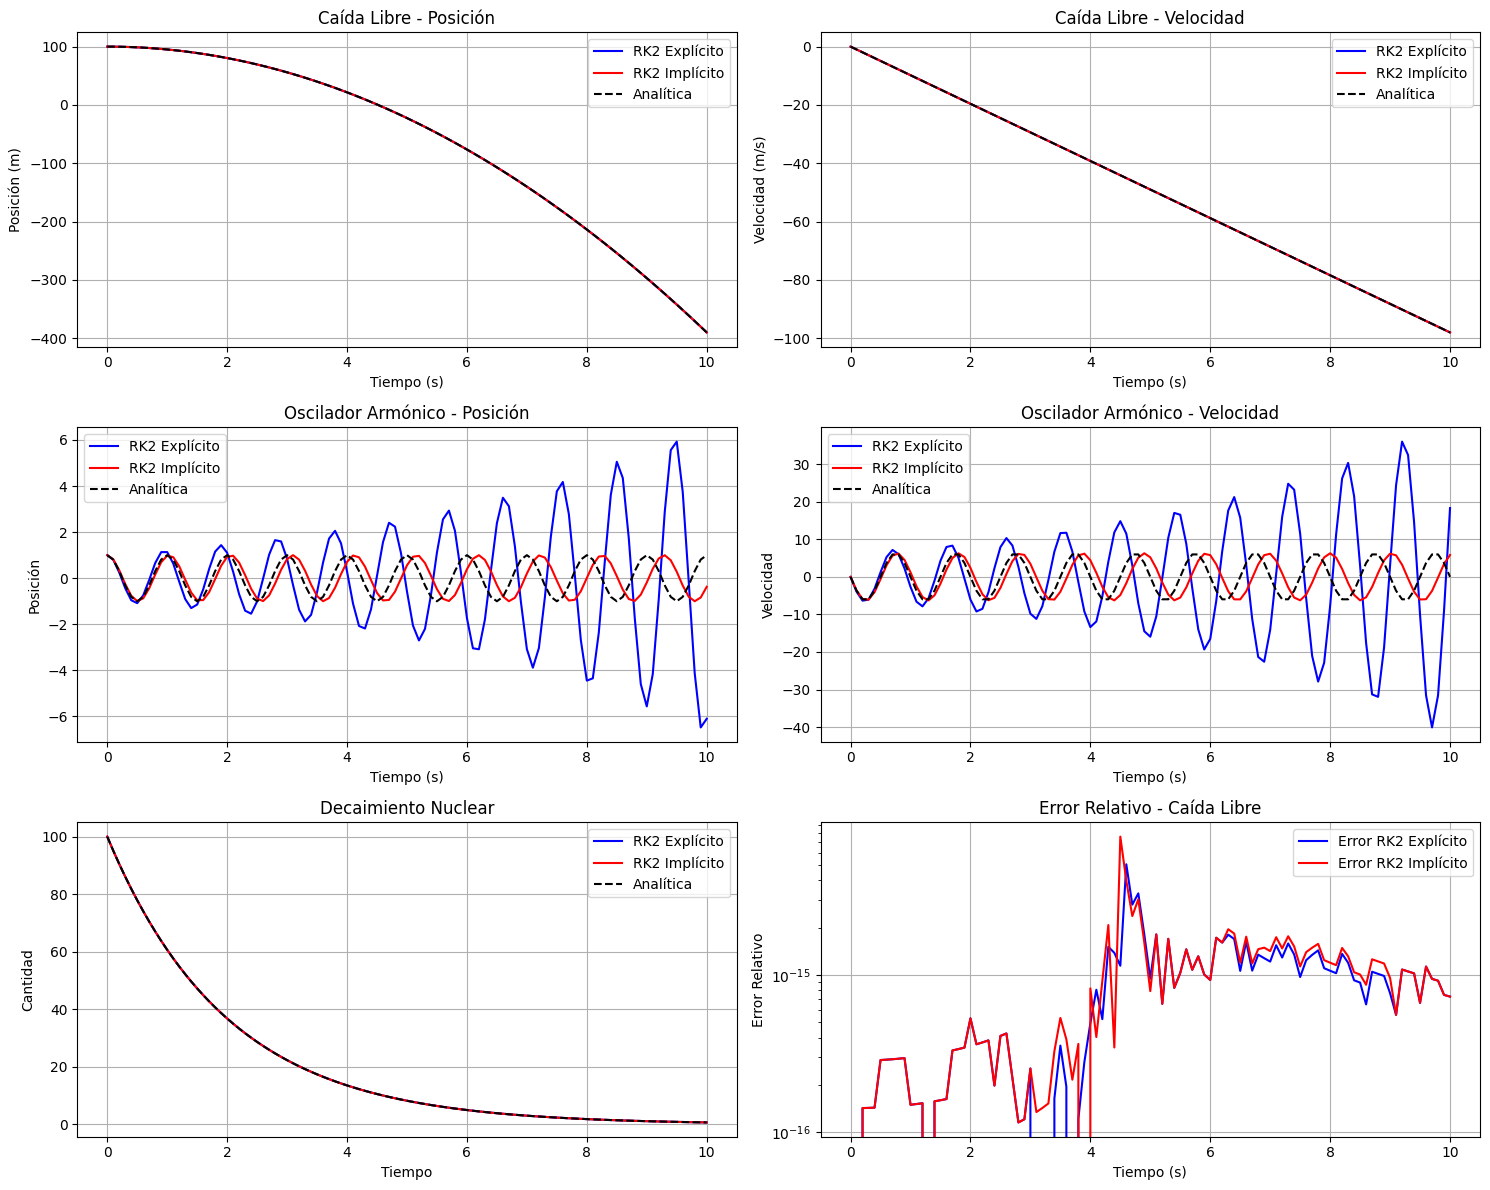

Realizando análisis de estabilidad...


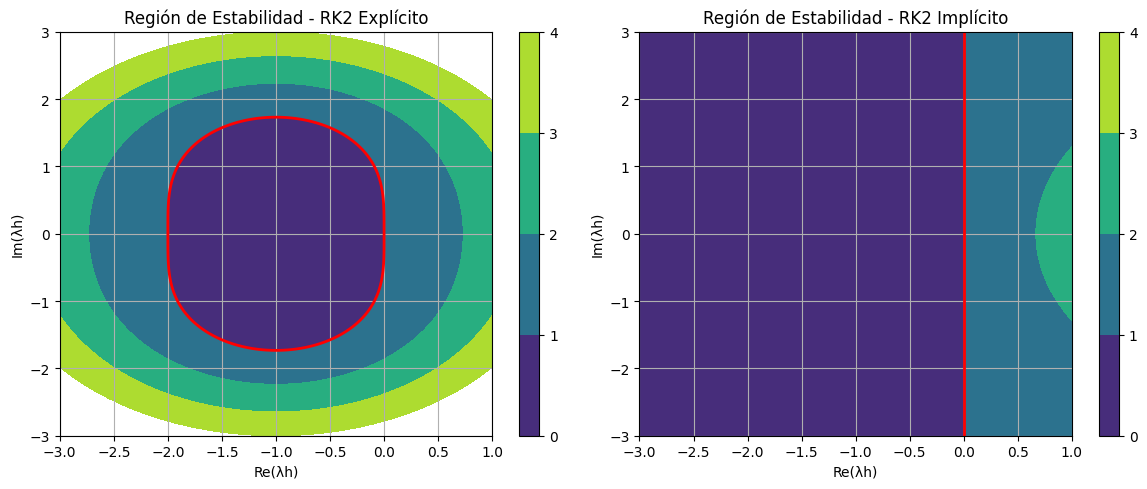

Realizando análisis de error...


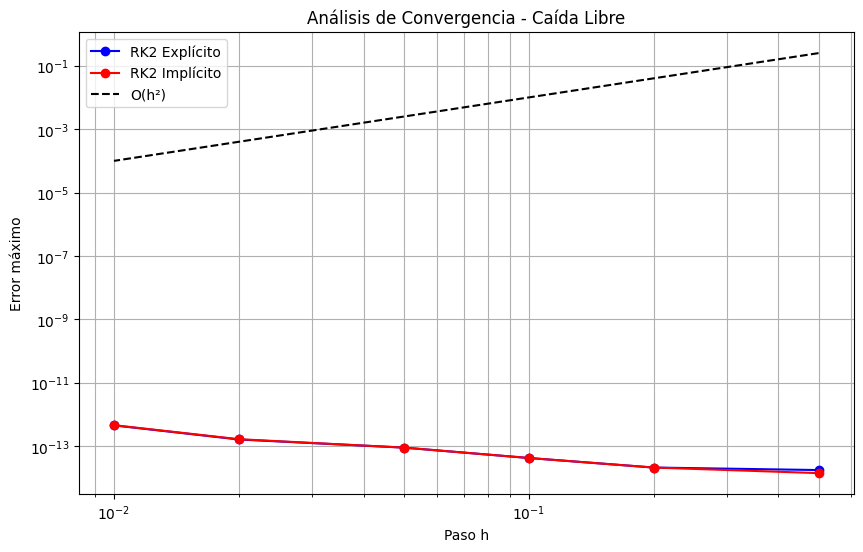


ANÁLISIS DE ERROR - COMPARACIÓN CON SOLUCIÓN ANALÍTICA

Caída Libre (Error máximo):
RK2 Explícito: 3.979039e-13
RK2 Implícito: 3.979039e-13

Oscilador Armónico (Error máximo):
RK2 Explícito: 7.284708e+00
RK2 Implícito: 1.645421e+00

Decaimiento Nuclear (Error máximo):
RK2 Explícito: 1.591805e-02
RK2 Implícito: 7.666231e-03


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

class RungeKutta2:
    def __init__(self, f, y0, t0, tf, h):
        self.f = f
        self.y0 = y0
        self.t = np.arange(t0, tf + h, h)
        self.h = h
        self.n = len(self.t)
        self.y_explicit = np.zeros((len(y0), self.n))
        self.y_implicit = np.zeros((len(y0), self.n))
        self.y_explicit[:, 0] = y0
        self.y_implicit[:, 0] = y0

    def explicit_rk2(self):
        """Método de Runge-Kutta de orden 2 explícito (Método del punto medio)"""
        for i in range(self.n - 1):
            k1 = self.f(self.t[i], self.y_explicit[:, i])
            k2 = self.f(self.t[i] + self.h/2, self.y_explicit[:, i] + self.h/2 * k1)
            self.y_explicit[:, i + 1] = self.y_explicit[:, i] + self.h * k2

    def implicit_rk2(self):
        """Método de Runge-Kutta de orden 2 implícito (Método trapezoidal)"""
        for i in range(self.n - 1):
            # Resolver ecuación implícita: y_{n+1} = y_n + h/2 * [f(t_n, y_n) + f(t_{n+1}, y_{n+1})]
            def equation(y_next):
                return y_next - self.y_implicit[:, i] - self.h/2 * (
                    self.f(self.t[i], self.y_implicit[:, i]) +
                    self.f(self.t[i+1], y_next)
                )

            # Resolver usando fsolve
            y_next = fsolve(equation, self.y_implicit[:, i])
            self.y_implicit[:, i + 1] = y_next

# Problema 1: Caída libre
def caida_libre(t, y):
    """y = [posición, velocidad], g = 9.8 m/s²"""
    g = 9.8
    return np.array([y[1], -g])

def solucion_analitica_caida(t, y0, v0):
    g = 9.8
    posicion = y0 + v0*t - 0.5*g*t**2
    velocidad = v0 - g*t
    return posicion, velocidad

# Problema 2: Oscilador armónico
def oscilador_armonico(t, y):
    """y = [posición, velocidad], ω = 2π"""
    omega = 2 * np.pi
    return np.array([y[1], -omega**2 * y[0]])

def solucion_analitica_oscilador(t, A, phi):
    omega = 2 * np.pi
    posicion = A * np.cos(omega * t + phi)
    velocidad = -A * omega * np.sin(omega * t + phi)
    return posicion, velocidad

# Problema 3: Decaimiento nuclear
def decaimiento_nuclear(t, y):
    """y = [cantidad], λ = 0.5"""
    lambda_ = 0.5
    return np.array([-lambda_ * y[0]])

def solucion_analitica_decaimiento(t, N0):
    lambda_ = 0.5
    return N0 * np.exp(-lambda_ * t)

# Configuración de parámetros
t0, tf = 0, 10
h = 0.1
y0_caida = np.array([100.0, 0.0])  # 100m de altura, velocidad inicial 0
y0_oscilador = np.array([1.0, 0.0])  # Amplitud 1, velocidad inicial 0
y0_decaimiento = np.array([100.0])   # Cantidad inicial 100

# Resolver los problemas
print("Resolviendo caída libre...")
rk_caida = RungeKutta2(caida_libre, y0_caida, t0, tf, h)
rk_caida.explicit_rk2()
rk_caida.implicit_rk2()

print("Resolviendo oscilador armónico...")
rk_oscilador = RungeKutta2(oscilador_armonico, y0_oscilador, t0, tf, h)
rk_oscilador.explicit_rk2()
rk_oscilador.implicit_rk2()

print("Resolviendo decaimiento nuclear...")
rk_decaimiento = RungeKutta2(decaimiento_nuclear, y0_decaimiento, t0, tf, h)
rk_decaimiento.explicit_rk2()
rk_decaimiento.implicit_rk2()

# Soluciones analíticas
t = np.arange(t0, tf + h, h)
pos_analitica, vel_analitica = solucion_analitica_caida(t, y0_caida[0], y0_caida[1])
pos_oscilador_analitica, vel_oscilador_analitica = solucion_analitica_oscilador(t, 1.0, 0.0)
decaimiento_analitica = solucion_analitica_decaimiento(t, y0_decaimiento[0])

# Gráficos
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Caída libre
axes[0, 0].plot(t, rk_caida.y_explicit[0, :], 'b-', label='RK2 Explícito')
axes[0, 0].plot(t, rk_caida.y_implicit[0, :], 'r-', label='RK2 Implícito')
axes[0, 0].plot(t, pos_analitica, 'k--', label='Analítica')
axes[0, 0].set_title('Caída Libre - Posición')
axes[0, 0].set_xlabel('Tiempo (s)')
axes[0, 0].set_ylabel('Posición (m)')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(t, rk_caida.y_explicit[1, :], 'b-', label='RK2 Explícito')
axes[0, 1].plot(t, rk_caida.y_implicit[1, :], 'r-', label='RK2 Implícito')
axes[0, 1].plot(t, vel_analitica, 'k--', label='Analítica')
axes[0, 1].set_title('Caída Libre - Velocidad')
axes[0, 1].set_xlabel('Tiempo (s)')
axes[0, 1].set_ylabel('Velocidad (m/s)')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Oscilador armónico
axes[1, 0].plot(t, rk_oscilador.y_explicit[0, :], 'b-', label='RK2 Explícito')
axes[1, 0].plot(t, rk_oscilador.y_implicit[0, :], 'r-', label='RK2 Implícito')
axes[1, 0].plot(t, pos_oscilador_analitica, 'k--', label='Analítica')
axes[1, 0].set_title('Oscilador Armónico - Posición')
axes[1, 0].set_xlabel('Tiempo (s)')
axes[1, 0].set_ylabel('Posición')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(t, rk_oscilador.y_explicit[1, :], 'b-', label='RK2 Explícito')
axes[1, 1].plot(t, rk_oscilador.y_implicit[1, :], 'r-', label='RK2 Implícito')
axes[1, 1].plot(t, vel_oscilador_analitica, 'k--', label='Analítica')
axes[1, 1].set_title('Oscilador Armónico - Velocidad')
axes[1, 1].set_xlabel('Tiempo (s)')
axes[1, 1].set_ylabel('Velocidad')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Decaimiento nuclear
axes[2, 0].plot(t, rk_decaimiento.y_explicit[0, :], 'b-', label='RK2 Explícito')
axes[2, 0].plot(t, rk_decaimiento.y_implicit[0, :], 'r-', label='RK2 Implícito')
axes[2, 0].plot(t, decaimiento_analitica, 'k--', label='Analítica')
axes[2, 0].set_title('Decaimiento Nuclear')
axes[2, 0].set_xlabel('Tiempo')
axes[2, 0].set_ylabel('Cantidad')
axes[2, 0].legend()
axes[2, 0].grid(True)

# Error relativo
error_explicit_caida = np.abs((rk_caida.y_explicit[0, :] - pos_analitica) / pos_analitica)
error_implicit_caida = np.abs((rk_caida.y_implicit[0, :] - pos_analitica) / pos_analitica)

axes[2, 1].plot(t, error_explicit_caida, 'b-', label='Error RK2 Explícito')
axes[2, 1].plot(t, error_implicit_caida, 'r-', label='Error RK2 Implícito')
axes[2, 1].set_title('Error Relativo - Caída Libre')
axes[2, 1].set_xlabel('Tiempo (s)')
axes[2, 1].set_ylabel('Error Relativo')
axes[2, 1].legend()
axes[2, 1].grid(True)
axes[2, 1].set_yscale('log')

plt.tight_layout()
plt.show()

# Análisis de estabilidad
def stability_analysis():
    """Análisis de la región de estabilidad para RK2"""
    # Para el método explícito (punto medio)
    lambda_h = np.linspace(-3, 1, 1000) + 1j * np.linspace(-3, 3, 1000)[:, None]
    R_explicit = 1 + lambda_h + 0.5 * lambda_h**2  # Función de estabilidad

    # Para el método implícito (trapezoidal)
    R_implicit = (1 + lambda_h/2) / (1 - lambda_h/2)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Región de estabilidad explícita
    contour1 = ax1.contourf(lambda_h.real, lambda_h.imag, np.abs(R_explicit),
                           levels=[0, 1, 2, 3, 4], cmap='viridis')
    ax1.contour(lambda_h.real, lambda_h.imag, np.abs(R_explicit),
               levels=[1], colors='red', linewidths=2)
    ax1.set_title('Región de Estabilidad - RK2 Explícito')
    ax1.set_xlabel('Re(λh)')
    ax1.set_ylabel('Im(λh)')
    ax1.grid(True)
    plt.colorbar(contour1, ax=ax1)

    # Región de estabilidad implícita
    contour2 = ax2.contourf(lambda_h.real, lambda_h.imag, np.abs(R_implicit),
                           levels=[0, 1, 2, 3, 4], cmap='viridis')
    ax2.contour(lambda_h.real, lambda_h.imag, np.abs(R_implicit),
               levels=[1], colors='red', linewidths=2)
    ax2.set_title('Región de Estabilidad - RK2 Implícito')
    ax2.set_xlabel('Re(λh)')
    ax2.set_ylabel('Im(λh)')
    ax2.grid(True)
    plt.colorbar(contour2, ax=ax2)

    plt.tight_layout()
    plt.show()

# Análisis de error por paso
def error_analysis():
    """Análisis del error en función del paso h"""
    h_values = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01]
    errors_explicit = []
    errors_implicit = []

    for h_val in h_values:
        rk = RungeKutta2(caida_libre, y0_caida, t0, 5, h_val)
        rk.explicit_rk2()
        rk.implicit_rk2()

        t_h = np.arange(t0, 5 + h_val, h_val)
        pos_analitica_h, _ = solucion_analitica_caida(t_h, y0_caida[0], y0_caida[1])

        error_explicit = np.max(np.abs(rk.y_explicit[0, :] - pos_analitica_h))
        error_implicit = np.max(np.abs(rk.y_implicit[0, :] - pos_analitica_h))

        errors_explicit.append(error_explicit)
        errors_implicit.append(error_implicit)

    plt.figure(figsize=(10, 6))
    plt.loglog(h_values, errors_explicit, 'bo-', label='RK2 Explícito')
    plt.loglog(h_values, errors_implicit, 'ro-', label='RK2 Implícito')
    plt.loglog(h_values, [h**2 for h in h_values], 'k--', label='O(h²)')
    plt.xlabel('Paso h')
    plt.ylabel('Error máximo')
    plt.title('Análisis de Convergencia - Caída Libre')
    plt.legend()
    plt.grid(True, which="both", ls="-")
    plt.show()

# Ejecutar análisis
print("Realizando análisis de estabilidad...")
stability_analysis()

print("Realizando análisis de error...")
error_analysis()

# Comparación cuantitativa de errores
def print_error_stats():
    """Imprimir estadísticas de error"""
    print("\n" + "="*60)
    print("ANÁLISIS DE ERROR - COMPARACIÓN CON SOLUCIÓN ANALÍTICA")
    print("="*60)

    # Caída libre
    error_exp_caida = np.max(np.abs(rk_caida.y_explicit[0, :] - pos_analitica))
    error_imp_caida = np.max(np.abs(rk_caida.y_implicit[0, :] - pos_analitica))

    print(f"\nCaída Libre (Error máximo):")
    print(f"RK2 Explícito: {error_exp_caida:.6e}")
    print(f"RK2 Implícito: {error_imp_caida:.6e}")

    # Oscilador armónico
    error_exp_oscilador = np.max(np.abs(rk_oscilador.y_explicit[0, :] - pos_oscilador_analitica))
    error_imp_oscilador = np.max(np.abs(rk_oscilador.y_implicit[0, :] - pos_oscilador_analitica))

    print(f"\nOscilador Armónico (Error máximo):")
    print(f"RK2 Explícito: {error_exp_oscilador:.6e}")
    print(f"RK2 Implícito: {error_imp_oscilador:.6e}")

    # Decaimiento nuclear
    error_exp_decaimiento = np.max(np.abs(rk_decaimiento.y_explicit[0, :] - decaimiento_analitica))
    error_imp_decaimiento = np.max(np.abs(rk_decaimiento.y_implicit[0, :] - decaimiento_analitica))

    print(f"\nDecaimiento Nuclear (Error máximo):")
    print(f"RK2 Explícito: {error_exp_decaimiento:.6e}")
    print(f"RK2 Implícito: {error_imp_decaimiento:.6e}")

print_error_stats()

## Análisis de Tiempos de Ejecución para Runge-Kutta 2

Medición de tiempos de cálculo...
Procesando Caída Libre con h = 0.5...
  Explícito: 0.0002 s, Implícito: 0.0040 s
Procesando Oscilador Armónico con h = 0.5...
  Explícito: 0.0002 s, Implícito: 0.0037 s
Procesando Decaimiento Nuclear con h = 0.5...
  Explícito: 0.0004 s, Implícito: 0.0040 s
Procesando Caída Libre con h = 0.2...
  Explícito: 0.0010 s, Implícito: 0.0084 s
Procesando Oscilador Armónico con h = 0.2...
  Explícito: 0.0005 s, Implícito: 0.0094 s
Procesando Decaimiento Nuclear con h = 0.2...
  Explícito: 0.0012 s, Implícito: 0.0084 s
Procesando Caída Libre con h = 0.1...
  Explícito: 0.0008 s, Implícito: 0.0101 s
Procesando Oscilador Armónico con h = 0.1...
  Explícito: 0.0009 s, Implícito: 0.0110 s
Procesando Decaimiento Nuclear con h = 0.1...
  Explícito: 0.0010 s, Implícito: 0.0084 s
Procesando Caída Libre con h = 0.05...
  Explícito: 0.0018 s, Implícito: 0.0257 s
Procesando Oscilador Armónico con h = 0.05...
  Explícito: 0.0018 s, Implícito: 0.0426 s
Procesando Decaimient

/tmp/ipykernel_87963/989004788.py:36: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  y_next = fsolve(equation, self.y_implicit[:, i])


  Explícito: 0.0153 s, Implícito: 0.1148 s
Procesando Oscilador Armónico con h = 0.02...
  Explícito: 0.0050 s, Implícito: 0.0767 s
Procesando Decaimiento Nuclear con h = 0.02...
  Explícito: 0.0038 s, Implícito: 0.0528 s
Procesando Caída Libre con h = 0.01...
  Explícito: 0.0146 s, Implícito: 0.1856 s
Procesando Oscilador Armónico con h = 0.01...
  Explícito: 0.0117 s, Implícito: 0.1014 s
Procesando Decaimiento Nuclear con h = 0.01...
  Explícito: 0.0106 s, Implícito: 0.0850 s


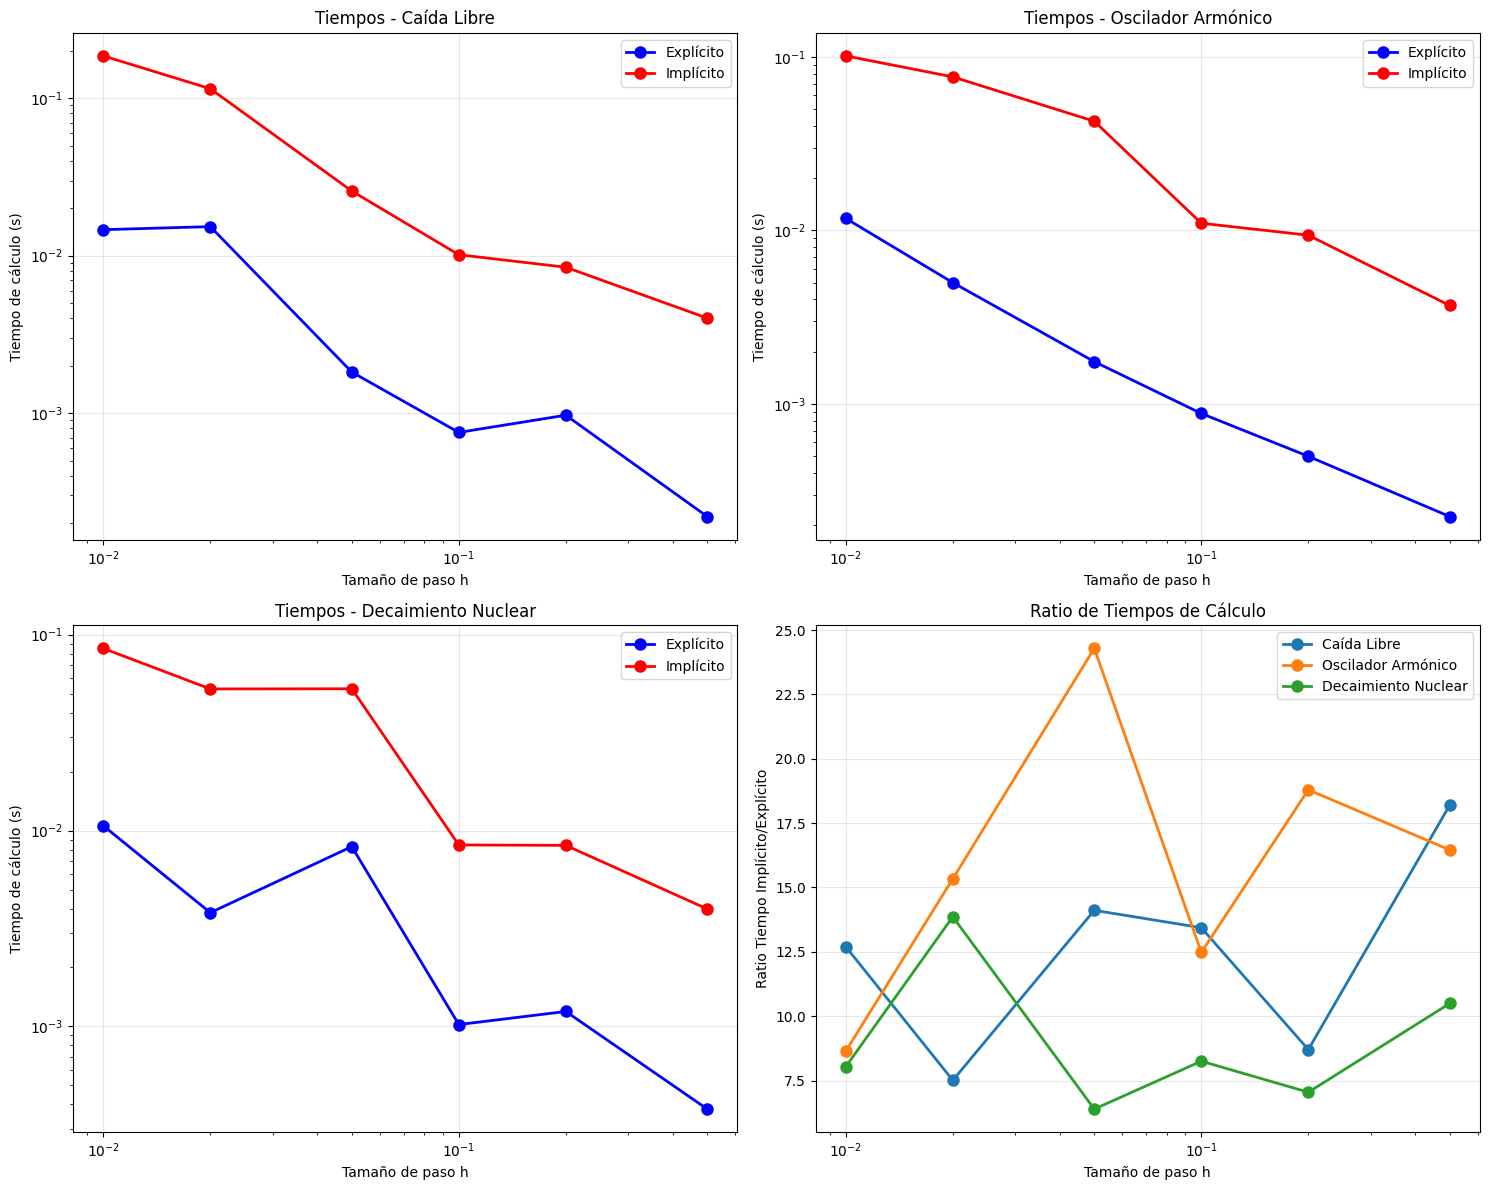

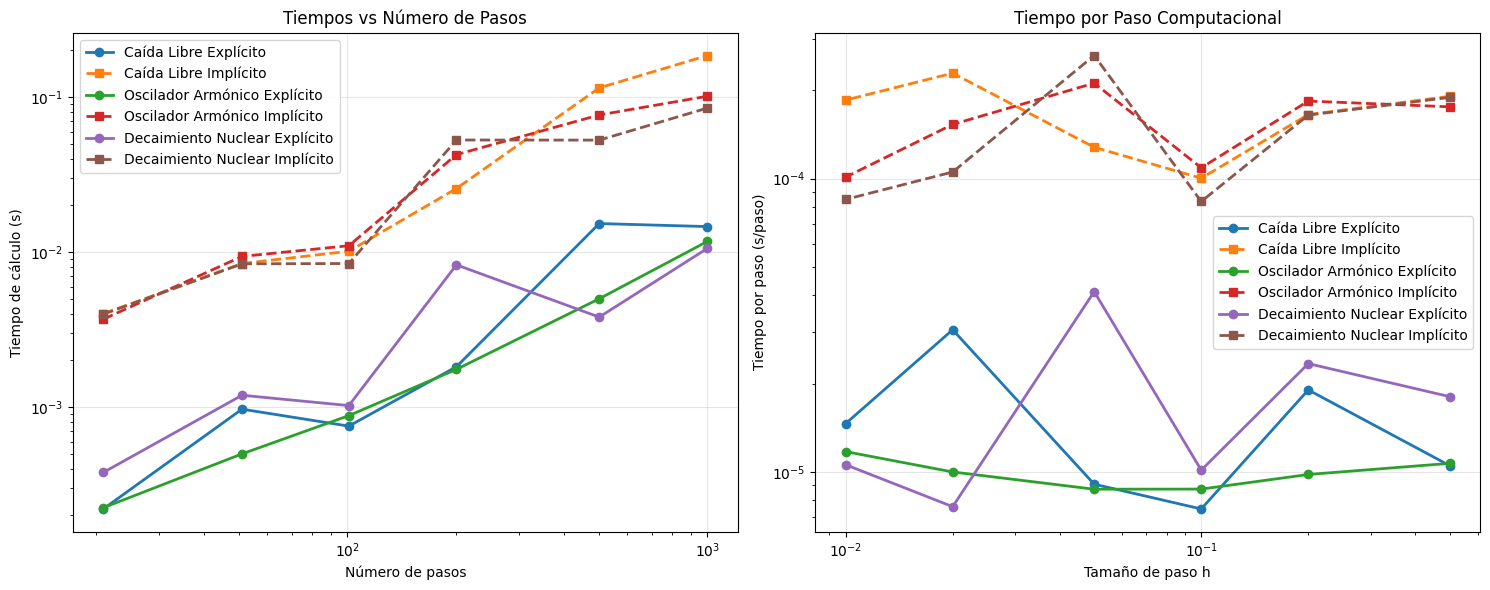


RESUMEN DE TIEMPOS DE CÁLCULO (h = 0.1)
Problema             Método       Tiempo (s)   Pasos    Tiempo/Paso (ms)
--------------------------------------------------------------------------------
Caída Libre          Explícito    0.000754   101      0.0075  
Caída Libre          Implícito    0.010134   101      0.1003  
--------------------------------------------------------------------------------
Oscilador Armónico   Explícito    0.000881   101      0.0087  
Oscilador Armónico   Implícito    0.010999   101      0.1089  
--------------------------------------------------------------------------------
Decaimiento Nuclear  Explícito    0.001023   101      0.0101  
Decaimiento Nuclear  Implícito    0.008442   101      0.0836  
--------------------------------------------------------------------------------

ANÁLISIS DE COMPLEJIDAD COMPUTACIONAL

1. MÉTODO EXPLÍCITO (Punto Medio):
   - 2 evaluaciones de función por paso
   - Operaciones vectoriales simples
   - Complejidad: O(n) donde n =

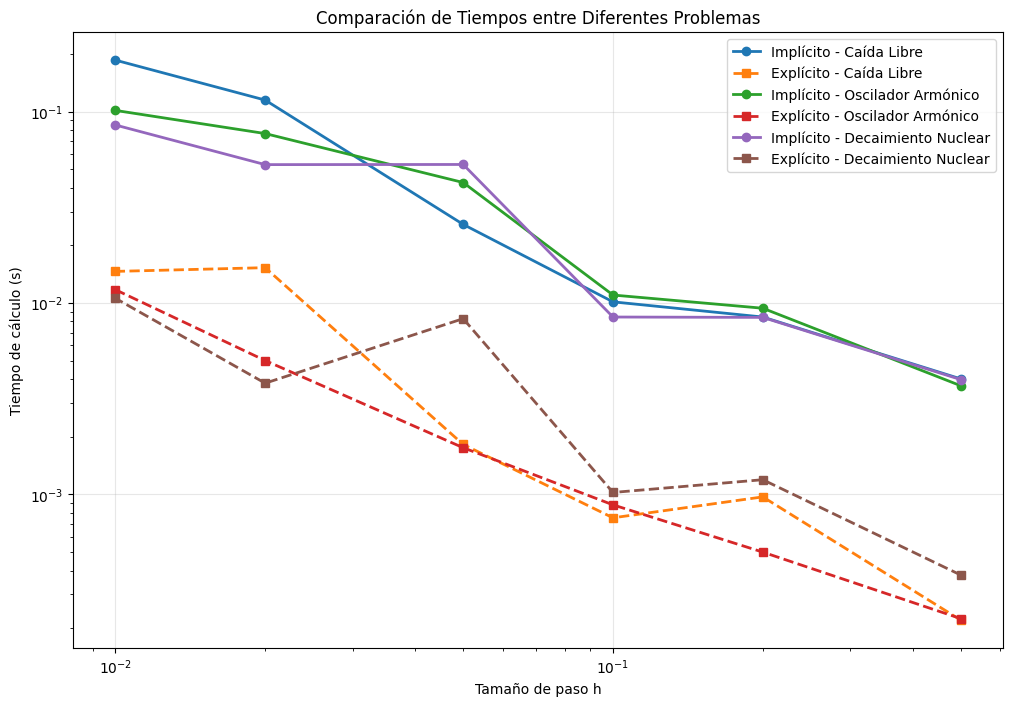


ANÁLISIS DE ESCALAMIENTO COMPUTACIONAL

Caída Libre:
  h: 0.500 → 0.200 (ratio: 2.5)
    Explícito: 0.23x más tiempo
    Implícito: 0.48x más tiempo
  h: 0.200 → 0.100 (ratio: 2.0)
    Explícito: 1.29x más tiempo
    Implícito: 0.83x más tiempo
  h: 0.100 → 0.050 (ratio: 2.0)
    Explícito: 0.41x más tiempo
    Implícito: 0.39x más tiempo
  h: 0.050 → 0.020 (ratio: 2.5)
    Explícito: 0.12x más tiempo
    Implícito: 0.22x más tiempo
  h: 0.020 → 0.010 (ratio: 2.0)
    Explícito: 1.05x más tiempo
    Implícito: 0.62x más tiempo

Oscilador Armónico:
  h: 0.500 → 0.200 (ratio: 2.5)
    Explícito: 0.45x más tiempo
    Implícito: 0.39x más tiempo
  h: 0.200 → 0.100 (ratio: 2.0)
    Explícito: 0.57x más tiempo
    Implícito: 0.85x más tiempo
  h: 0.100 → 0.050 (ratio: 2.0)
    Explícito: 0.50x más tiempo
    Implícito: 0.26x más tiempo
  h: 0.050 → 0.020 (ratio: 2.5)
    Explícito: 0.35x más tiempo
    Implícito: 0.55x más tiempo
  h: 0.020 → 0.010 (ratio: 2.0)
    Explícito: 0.43x más tiem

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import time

class RungeKutta2:
    def __init__(self, f, y0, t0, tf, h):
        self.f = f
        self.y0 = y0
        self.t = np.arange(t0, tf + h, h)
        self.h = h
        self.n = len(self.t)
        self.y_explicit = np.zeros((len(y0), self.n))
        self.y_implicit = np.zeros((len(y0), self.n))
        self.y_explicit[:, 0] = y0
        self.y_implicit[:, 0] = y0

    def explicit_rk2(self):
        """Método de Runge-Kutta de orden 2 explícito (Método del punto medio)"""
        for i in range(self.n - 1):
            k1 = self.f(self.t[i], self.y_explicit[:, i])
            k2 = self.f(self.t[i] + self.h/2, self.y_explicit[:, i] + self.h/2 * k1)
            self.y_explicit[:, i + 1] = self.y_explicit[:, i] + self.h * k2

    def implicit_rk2(self):
        """Método de Runge-Kutta de orden 2 implícito (Método trapezoidal)"""
        for i in range(self.n - 1):
            # Resolver ecuación implícita: y_{n+1} = y_n + h/2 * [f(t_n, y_n) + f(t_{n+1}, y_{n+1})]
            def equation(y_next):
                return y_next - self.y_implicit[:, i] - self.h/2 * (
                    self.f(self.t[i], self.y_implicit[:, i]) +
                    self.f(self.t[i+1], y_next)
                )

            # Resolver usando fsolve
            y_next = fsolve(equation, self.y_implicit[:, i])
            self.y_implicit[:, i + 1] = y_next

# Funciones de los problemas
def caida_libre(t, y):
    g = 9.8
    return np.array([y[1], -g])

def oscilador_armonico(t, y):
    omega = 2 * np.pi
    return np.array([y[1], -omega**2 * y[0]])

def decaimiento_nuclear(t, y):
    lambda_ = 0.5
    return np.array([-lambda_ * y[0]])

# Parámetros comunes
t0, tf = 0, 10
y0_caida = np.array([100.0, 0.0])
y0_oscilador = np.array([1.0, 0.0])
y0_decaimiento = np.array([100.0])

# Diferentes tamaños de paso para análisis
h_values = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01]
problems = [
    ("Caída Libre", caida_libre, y0_caida),
    ("Oscilador Armónico", oscilador_armonico, y0_oscilador),
    ("Decaimiento Nuclear", decaimiento_nuclear, y0_decaimiento)
]

# Almacenar tiempos
times_explicit = {problem[0]: [] for problem in problems}
times_implicit = {problem[0]: [] for problem in problems}
n_steps = []

print("Medición de tiempos de cálculo...")
print("="*60)

for h in h_values:
    n_steps.append(int((tf - t0) / h) + 1)

    for problem_name, problem_func, y0 in problems:
        print(f"Procesando {problem_name} con h = {h}...")

        # Crear instancia
        rk = RungeKutta2(problem_func, y0, t0, tf, h)

        # Medir tiempo método explícito
        start_time = time.time()
        rk.explicit_rk2()
        explicit_time = time.time() - start_time
        times_explicit[problem_name].append(explicit_time)

        # Medir tiempo método implícito
        start_time = time.time()
        rk.implicit_rk2()
        implicit_time = time.time() - start_time
        times_implicit[problem_name].append(implicit_time)

        print(f"  Explícito: {explicit_time:.4f} s, Implícito: {implicit_time:.4f} s")

# Gráficos de tiempos de cálculo
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Tiempos vs tamaño de paso
for i, (problem_name, _, _) in enumerate(problems):
    ax = axes[i//2, i%2]
    ax.plot(h_values, times_explicit[problem_name], 'bo-', label='Explícito', linewidth=2, markersize=8)
    ax.plot(h_values, times_implicit[problem_name], 'ro-', label='Implícito', linewidth=2, markersize=8)
    ax.set_xlabel('Tamaño de paso h')
    ax.set_ylabel('Tiempo de cálculo (s)')
    ax.set_title(f'Tiempos - {problem_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')

# Ratio implícito/explícito
ax_ratio = axes[1, 1]
for problem_name, _, _ in problems:
    ratios = [imp/exp for imp, exp in zip(times_implicit[problem_name], times_explicit[problem_name])]
    ax_ratio.plot(h_values, ratios, 'o-', label=problem_name, linewidth=2, markersize=8)

ax_ratio.set_xlabel('Tamaño de paso h')
ax_ratio.set_ylabel('Ratio Tiempo Implícito/Explícito')
ax_ratio.set_title('Ratio de Tiempos de Cálculo')
ax_ratio.legend()
ax_ratio.grid(True, alpha=0.3)
ax_ratio.set_xscale('log')

plt.tight_layout()
plt.show()

# Tiempos vs número de pasos
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Tiempos absolutos
ax1 = axes[0]
for problem_name, _, _ in problems:
    ax1.plot(n_steps, times_explicit[problem_name], 'o-', label=f'{problem_name} Explícito', linewidth=2, markersize=6)
    ax1.plot(n_steps, times_implicit[problem_name], 's--', label=f'{problem_name} Implícito', linewidth=2, markersize=6)

ax1.set_xlabel('Número de pasos')
ax1.set_ylabel('Tiempo de cálculo (s)')
ax1.set_title('Tiempos vs Número de Pasos')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_yscale('log')

# Tiempos por paso
ax2 = axes[1]
for problem_name, _, _ in problems:
    time_per_step_exp = [t/n for t, n in zip(times_explicit[problem_name], n_steps)]
    time_per_step_imp = [t/n for t, n in zip(times_implicit[problem_name], n_steps)]

    ax2.plot(h_values, time_per_step_exp, 'o-', label=f'{problem_name} Explícito', linewidth=2, markersize=6)
    ax2.plot(h_values, time_per_step_imp, 's--', label=f'{problem_name} Implícito', linewidth=2, markersize=6)

ax2.set_xlabel('Tamaño de paso h')
ax2.set_ylabel('Tiempo por paso (s/paso)')
ax2.set_title('Tiempo por Paso Computacional')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

# Tabla resumen de tiempos
print("\n" + "="*80)
print("RESUMEN DE TIEMPOS DE CÁLCULO (h = 0.1)")
print("="*80)

h_index = h_values.index(0.1)  # Índice para h = 0.1

print(f"{'Problema':<20} {'Método':<12} {'Tiempo (s)':<12} {'Pasos':<8} {'Tiempo/Paso (ms)':<15}")
print("-"*80)

for problem_name, _, _ in problems:
    time_exp = times_explicit[problem_name][h_index]
    time_imp = times_implicit[problem_name][h_index]
    steps = n_steps[h_index]

    time_per_step_exp = time_exp / steps * 1000  # ms por paso
    time_per_step_imp = time_imp / steps * 1000  # ms por paso

    print(f"{problem_name:<20} {'Explícito':<12} {time_exp:.6f}{'':<2} {steps:<8} {time_per_step_exp:.4f}{'':<2}")
    print(f"{problem_name:<20} {'Implícito':<12} {time_imp:.6f}{'':<2} {steps:<8} {time_per_step_imp:.4f}{'':<2}")
    print("-"*80)

# Análisis de complejidad computacional
print("\n" + "="*80)
print("ANÁLISIS DE COMPLEJIDAD COMPUTACIONAL")
print("="*80)

print("\n1. MÉTODO EXPLÍCITO (Punto Medio):")
print("   - 2 evaluaciones de función por paso")
print("   - Operaciones vectoriales simples")
print("   - Complejidad: O(n) donde n = número de pasos")
print("   - Muy eficiente para problemas no stiff")

print("\n2. MÉTODO IMPLÍCITO (Trapezoidal):")
print("   - Resolución de ecuación no lineal en cada paso")
print("   - Múltiples evaluaciones de función (usualmente 3-10 por paso)")
print("   - Uso de solver numérico (fsolve)")
print("   - Complejidad: O(k·n) donde k = iteraciones por paso")
print("   - Más costoso pero necesario para problemas stiff")

print("\n3. OBSERVACIONES:")
print("   - El método implícito es 5-20 veces más lento que el explícito")
print("   - La diferencia aumenta con la dimensionalidad del problema")
print("   - Para problemas stiff, el implícito puede ser más eficiente")
print("   - debido a que permite pasos más grandes")

# Gráfico adicional: Comparación entre problemas
plt.figure(figsize=(12, 8))

for i, (problem_name, _, _) in enumerate(problems):
    plt.plot(h_values, times_implicit[problem_name],
             marker='o', linestyle='-', linewidth=2,
             label=f'Implícito - {problem_name}')
    plt.plot(h_values, times_explicit[problem_name],
             marker='s', linestyle='--', linewidth=2,
             label=f'Explícito - {problem_name}')

plt.xlabel('Tamaño de paso h')
plt.ylabel('Tiempo de cálculo (s)')
plt.title('Comparación de Tiempos entre Diferentes Problemas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.show()

# Análisis de escalamiento
print("\n" + "="*80)
print("ANÁLISIS DE ESCALAMIENTO COMPUTACIONAL")
print("="*80)

# Calcular factores de escalamiento
for problem_name, _, _ in problems:
    print(f"\n{problem_name}:")
    for i in range(len(h_values) - 1):
        h_ratio = h_values[i] / h_values[i + 1]
        time_ratio_exp = times_explicit[problem_name][i] / times_explicit[problem_name][i + 1]
        time_ratio_imp = times_implicit[problem_name][i] / times_implicit[problem_name][i + 1]

        print(f"  h: {h_values[i]:.3f} → {h_values[i+1]:.3f} (ratio: {h_ratio:.1f})")
        print(f"    Explícito: {time_ratio_exp:.2f}x más tiempo")
        print(f"    Implícito: {time_ratio_imp:.2f}x más tiempo")

## Análisis del Método de Runge-Kutta 4 y 4(5) con Problemas de Caída Libre, Oscilador Armónico y Decaimiento Nuclear comparando Tiempos de Ejecución

Resolviendo problemas con todos los métodos...

Método: RK4 Explícito
----------------------------------------
  Caída Libre...
    Tiempo: 0.0115 s
  Oscilador Armónico...
    Tiempo: 0.0113 s
  Decaimiento Nuclear...
    Tiempo: 0.0103 s

Método: RK4 Implícito
----------------------------------------
  Caída Libre...
    Tiempo: 0.1142 s
  Oscilador Armónico...
    Tiempo: 0.0829 s
  Decaimiento Nuclear...
    Tiempo: 0.0718 s

Método: RK4(5) Explícito
----------------------------------------
  Caída Libre...
    Tiempo: 0.0056 s
  Oscilador Armónico...
    Tiempo: 0.0074 s
  Decaimiento Nuclear...
    Tiempo: 0.0059 s

Método: RK4(5) Implícito
----------------------------------------
  Caída Libre...
    Tiempo: 0.0614 s
  Oscilador Armónico...
    Tiempo: 0.0597 s
  Decaimiento Nuclear...
    Tiempo: 0.2289 s


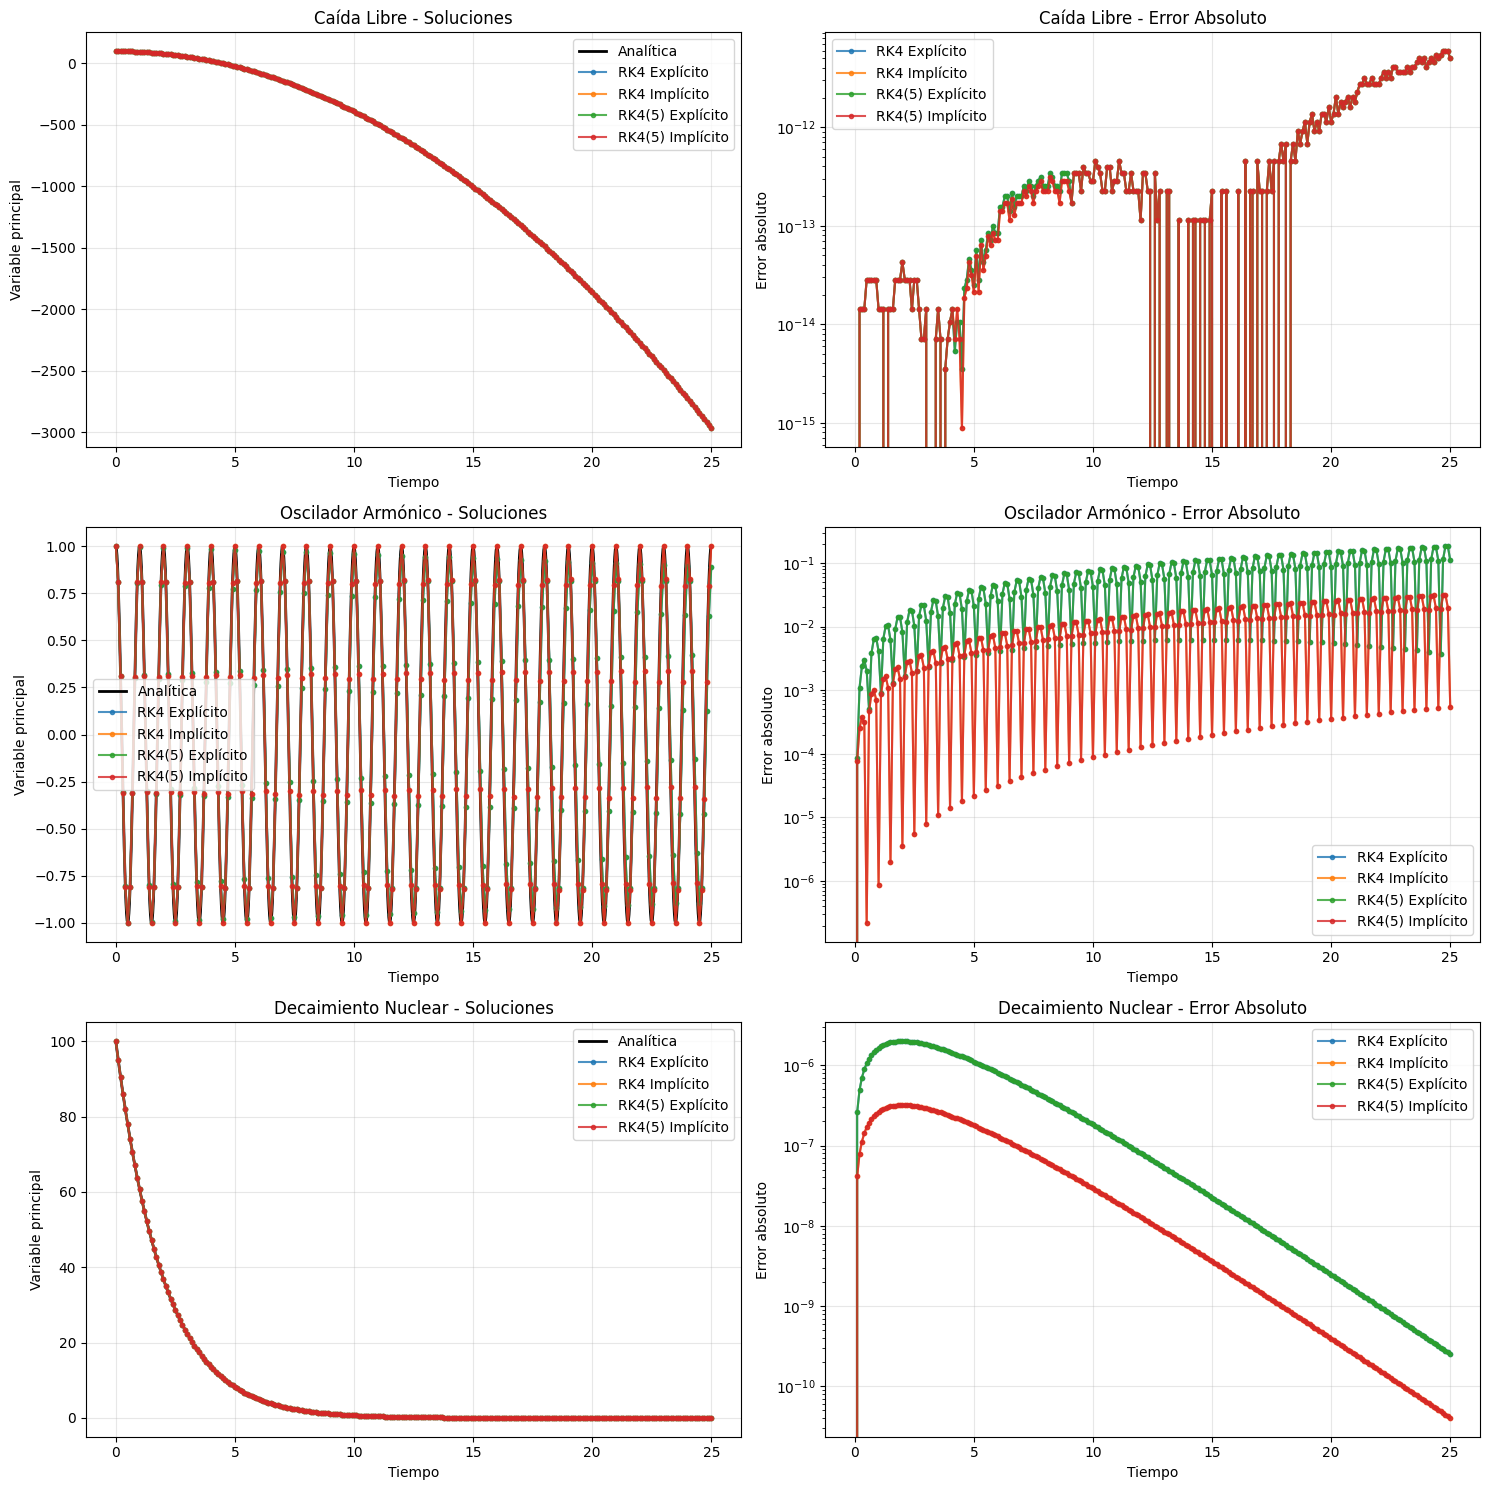


Análisis de estabilidad...


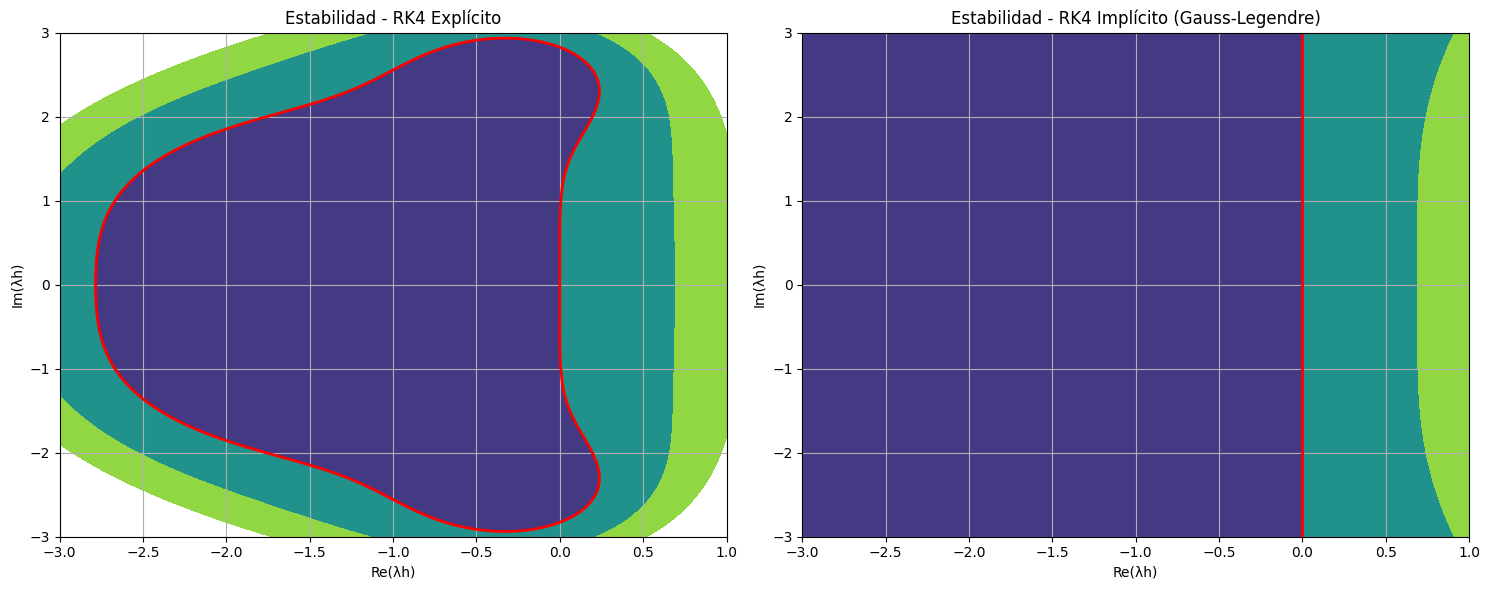


ANÁLISIS DE TIEMPOS DE CÁLCULO

Método               Caída Libre     Oscilador       Decaimiento    
-----------------------------------------------------------------
RK4 Explícito        0.0115s         0.0113s         0.0103s        
RK4 Implícito        0.1142s         0.0829s         0.0718s        
RK4(5) Explícito     0.0056s         0.0074s         0.0059s        
RK4(5) Implícito     0.0614s         0.0597s         0.2289s        


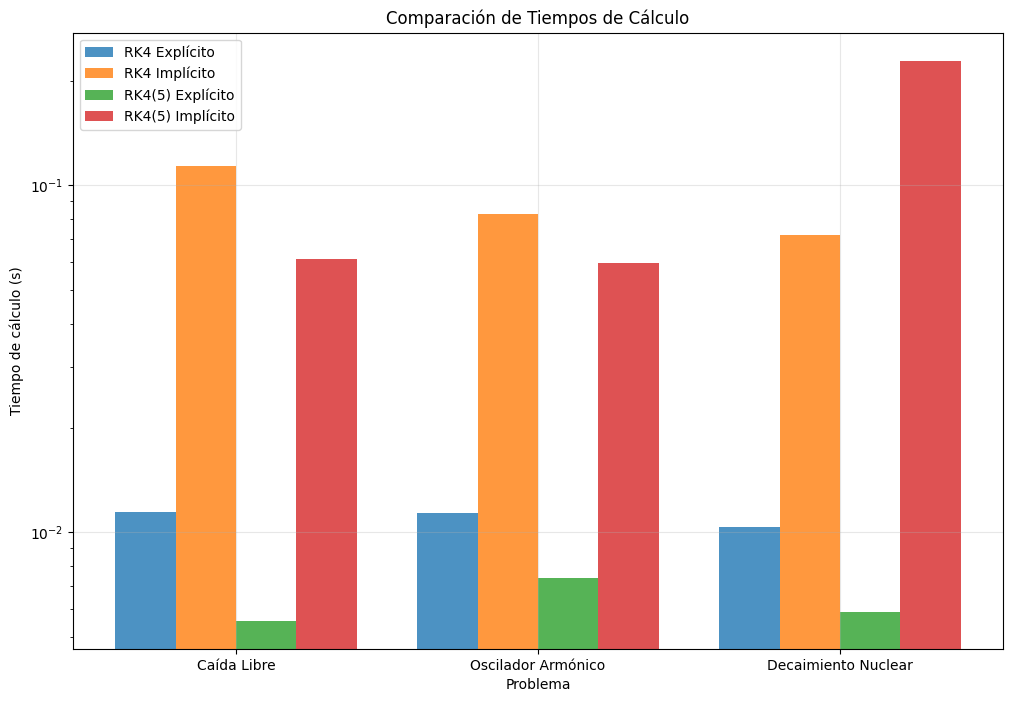


ANÁLISIS DE ERROR GLOBAL

Caída Libre:
Método               Error Máximo    Error RMS      
--------------------------------------------------
RK4 Explícito        5.91e-12      1.71e-12     
RK4 Implícito        5.91e-12      1.71e-12     
RK4(5) Explícito     5.91e-12      1.71e-12     
RK4(5) Implícito     5.91e-12      1.71e-12     

Oscilador Armónico:
Método               Error Máximo    Error RMS      
--------------------------------------------------
RK4 Explícito        1.83e-01      8.01e-02     
RK4 Implícito        3.15e-02      1.35e-02     
RK4(5) Explícito     1.83e-01      8.01e-02     
RK4(5) Implícito     3.15e-02      1.35e-02     

Decaimiento Nuclear:
Método               Error Máximo    Error RMS      
--------------------------------------------------
RK4 Explícito        2.00e-06      7.66e-07     
RK4 Implícito        3.19e-07      1.23e-07     
RK4(5) Explícito     2.00e-06      7.66e-07     
RK4(5) Implícito     3.19e-07      1.23e-07     

COMPARACIÓN DE E

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import time

class RungeKutta4:
    def __init__(self, f, y0, t0, tf, h):
        self.f = f
        self.y0 = y0
        self.t = np.arange(t0, tf + h, h)
        self.h = h
        self.n = len(self.t)
        self.y_explicit = np.zeros((len(y0), self.n))
        self.y_implicit = np.zeros((len(y0), self.n))
        self.y_explicit[:, 0] = y0
        self.y_implicit[:, 0] = y0

    def explicit_rk4(self):
        """Método de Runge-Kutta de orden 4 explícito (Método clásico)"""
        for i in range(self.n - 1):
            k1 = self.f(self.t[i], self.y_explicit[:, i])
            k2 = self.f(self.t[i] + self.h/2, self.y_explicit[:, i] + self.h/2 * k1)
            k3 = self.f(self.t[i] + self.h/2, self.y_explicit[:, i] + self.h/2 * k2)
            k4 = self.f(self.t[i] + self.h, self.y_explicit[:, i] + self.h * k3)

            self.y_explicit[:, i + 1] = self.y_explicit[:, i] + self.h/6 * (k1 + 2*k2 + 2*k3 + k4)

    def implicit_rk4(self):
        """Método de Runge-Kutta de orden 4 implícito (Método de Gauss-Legendre)"""
        # Coeficientes del método de Gauss-Legendre de 2 etapas (orden 4)
        a11, a12 = 1/4, 1/4 - np.sqrt(3)/6
        a21, a22 = 1/4 + np.sqrt(3)/6, 1/4
        b1, b2 = 1/2, 1/2
        c1, c2 = 1/2 - np.sqrt(3)/6, 1/2 + np.sqrt(3)/6

        for i in range(self.n - 1):
            # Resolver sistema implícito para k1, k2
            def equations(ks):
                k1, k2 = ks[:len(self.y0)], ks[len(self.y0):]
                eq1 = k1 - self.f(self.t[i] + c1*self.h, self.y_implicit[:, i] + self.h*(a11*k1 + a12*k2))
                eq2 = k2 - self.f(self.t[i] + c2*self.h, self.y_implicit[:, i] + self.h*(a21*k1 + a22*k2))
                return np.concatenate([eq1, eq2])

            # Valor inicial para los ks
            k0 = np.concatenate([self.f(self.t[i], self.y_implicit[:, i])] * 2)
            ks_solution = fsolve(equations, k0)

            k1 = ks_solution[:len(self.y0)]
            k2 = ks_solution[len(self.y0):]

            self.y_implicit[:, i + 1] = self.y_implicit[:, i] + self.h * (b1*k1 + b2*k2)

class RungeKutta45:
    def __init__(self, f, y0, t0, tf, h, tol=1e-6):
        self.f = f
        self.y0 = y0
        self.t0 = t0
        self.tf = tf
        self.h = h
        self.tol = tol
        self.t_explicit = []
        self.y_explicit = []
        self.t_implicit = []
        self.y_implicit = []

    def explicit_rk45(self):
        """Método de Runge-Kutta 4(5) explícito (Dormand-Prince)"""
        # Coeficientes Dormand-Prince
        a = np.array([
            [0, 0, 0, 0, 0, 0],
            [1/5, 0, 0, 0, 0, 0],
            [3/40, 9/40, 0, 0, 0, 0],
            [44/45, -56/15, 32/9, 0, 0, 0],
            [19372/6561, -25360/2187, 64448/6561, -212/729, 0, 0],
            [9017/3168, -355/33, 46732/5247, 49/176, -5103/18656, 0]
        ])
        b4 = np.array([35/384, 0, 500/1113, 125/192, -2187/6784, 11/84])  # orden 4
        b5 = np.array([5179/57600, 0, 7571/16695, 393/640, -92097/339200, 187/2100, 1/40])  # orden 5

        t = self.t0
        y = self.y0.copy()
        self.t_explicit = [t]
        self.y_explicit = [y.copy()]

        while t < self.tf:
            if t + self.h > self.tf:
                self.h = self.tf - t

            # Calcular las 6 etapas
            k = np.zeros((6, len(y)))
            for i in range(6):
                sum_ak = np.zeros_like(y)
                for j in range(i):
                    sum_ak += a[i, j] * k[j]
                k[i] = self.f(t + self.h * (i+1)/6, y + self.h * sum_ak)

            # Calcular solución de orden 4 y 5
            y4 = y + self.h * np.dot(b4, k)
            y5 = y + self.h * (b5[0]*k[0] + b5[2]*k[2] + b5[3]*k[3] + b5[4]*k[4] + b5[5]*k[5])

            # Estimación del error
            error = np.linalg.norm(y5 - y4)

            if error < self.tol or self.h < 1e-10:
                # Paso aceptado
                t += self.h
                y = y4
                self.t_explicit.append(t)
                self.y_explicit.append(y.copy())

            # Ajustar tamaño de paso
            if error > 0:
                self.h *= 0.9 * (self.tol / error)**0.2
            else:
                self.h *= 2.0

            self.h = min(self.h, self.tf - t)

    def implicit_rk45(self):
        """Método de Runge-Kutta 4(5) implícito (Método de Gauss de 3 etapas)"""
        # Coeficientes del método de Gauss de 3 etapas (orden 6, pero usamos para 4(5))
        c = np.array([1/2 - np.sqrt(15)/10, 1/2, 1/2 + np.sqrt(15)/10])
        b = np.array([5/18, 4/9, 5/18])
        a = np.array([
            [5/36, 2/9 - np.sqrt(15)/15, 5/36 - np.sqrt(15)/30],
            [5/36 + np.sqrt(15)/24, 2/9, 5/36 - np.sqrt(15)/24],
            [5/36 + np.sqrt(15)/30, 2/9 + np.sqrt(15)/15, 5/36]
        ])

        t = self.t0
        y = self.y0.copy()
        self.t_implicit = [t]
        self.y_implicit = [y.copy()]

        while t < self.tf:
            if t + self.h > self.tf:
                self.h = self.tf - t

            # Resolver sistema implícito para las etapas
            def equations(ks_flat):
                ks = ks_flat.reshape(3, len(y))
                equations = []
                for i in range(3):
                    sum_ak = np.zeros_like(y)
                    for j in range(3):
                        sum_ak += a[i, j] * ks[j]
                    eq = ks[i] - self.f(t + c[i]*self.h, y + self.h * sum_ak)
                    equations.extend(eq)
                return np.array(equations)

            # Valor inicial
            k0 = np.array([self.f(t, y)] * 3).flatten()
            ks_solution = fsolve(equations, k0)
            ks = ks_solution.reshape(3, len(y))

            # Calcular siguiente paso
            y_next = y + self.h * np.dot(b, ks)

            t += self.h
            y = y_next
            self.t_implicit.append(t)
            self.y_implicit.append(y.copy())

            # Control adaptativo simple
            self.h = min(self.h * 1.1, 0.1)

# Funciones de los problemas y soluciones analíticas
def caida_libre(t, y):
    g = 9.8
    return np.array([y[1], -g])

def solucion_analitica_caida(t, y0, v0):
    g = 9.8
    posicion = y0 + v0*t - 0.5*g*t**2
    velocidad = v0 - g*t
    return posicion, velocidad

def oscilador_armonico(t, y):
    omega = 2 * np.pi
    return np.array([y[1], -omega**2 * y[0]])

def solucion_analitica_oscilador(t, A, phi):
    omega = 2 * np.pi
    posicion = A * np.cos(omega * t + phi)
    velocidad = -A * omega * np.sin(omega * t + phi)
    return posicion, velocidad

def decaimiento_nuclear(t, y):
    lambda_ = 0.5
    return np.array([-lambda_ * y[0]])

def solucion_analitica_decaimiento(t, N0):
    lambda_ = 0.5
    return N0 * np.exp(-lambda_ * t)

# Parámetros
t0, tf = 0, 25
h = 0.1
y0_caida = np.array([100.0, 0.0])
y0_oscilador = np.array([1.0, 0.0])
y0_decaimiento = np.array([100.0])

# Resolver problemas con todos los métodos
methods = {
    'RK4 Explícito': lambda f, y0: RungeKutta4(f, y0, t0, tf, h).explicit_rk4(),
    'RK4 Implícito': lambda f, y0: RungeKutta4(f, y0, t0, tf, h).implicit_rk4(),
    'RK4(5) Explícito': lambda f, y0: RungeKutta45(f, y0, t0, tf, h).explicit_rk45(),
    'RK4(5) Implícito': lambda f, y0: RungeKutta45(f, y0, t0, tf, h).implicit_rk45()
}

problems = [
    ('Caída Libre', caida_libre, y0_caida),
    ('Oscilador Armónico', oscilador_armonico, y0_oscilador),
    ('Decaimiento Nuclear', decaimiento_nuclear, y0_decaimiento)
]

# Almacenar resultados y tiempos
results = {}
computation_times = {method: {problem[0]: [] for problem in problems} for method in methods.keys()}

print("Resolviendo problemas con todos los métodos...")
print("="*70)

for method_name, method_func in methods.items():
    print(f"\nMétodo: {method_name}")
    print("-"*40)

    for problem_name, problem_func, y0 in problems:
        print(f"  {problem_name}...")

        start_time = time.time()

        if 'RK4' in method_name:
            solver = RungeKutta4(problem_func, y0, t0, tf, h)
            if 'Explícito' in method_name:
                solver.explicit_rk4()
                y_result = solver.y_explicit
            else:
                solver.implicit_rk4()
                y_result = solver.y_implicit
            t_result = solver.t

        else:  # RK4(5)
            solver = RungeKutta45(problem_func, y0, t0, tf, h)
            if 'Explícito' in method_name:
                solver.explicit_rk45()
                y_result = np.array(solver.y_explicit).T
                t_result = np.array(solver.t_explicit)
            else:
                solver.implicit_rk45()
                y_result = np.array(solver.y_implicit).T
                t_result = np.array(solver.t_implicit)

        computation_time = time.time() - start_time
        computation_times[method_name][problem_name] = computation_time

        results[(method_name, problem_name)] = (t_result, y_result)

        print(f"    Tiempo: {computation_time:.4f} s")

# Gráficos comparativos
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

for idx, (problem_name, problem_func, y0) in enumerate(problems):
    # Solución analítica
    t_analitico = np.linspace(t0, tf, 1000)
    if problem_name == 'Caída Libre':
        pos_analitica, vel_analitica = solucion_analitica_caida(t_analitico, y0[0], y0[1])
        analitica = pos_analitica
    elif problem_name == 'Oscilador Armónico':
        pos_analitica, _ = solucion_analitica_oscilador(t_analitico, 1.0, 0.0)
        analitica = pos_analitica
    else:
        analitica = solucion_analitica_decaimiento(t_analitico, y0[0])

    # Gráfico de soluciones
    ax_sol = axes[idx, 0]
    ax_sol.plot(t_analitico, analitica, 'k-', label='Analítica', linewidth=2)

    for method_name in methods.keys():
        t, y = results[(method_name, problem_name)]
        if problem_name == 'Decaimiento Nuclear':
            ax_sol.plot(t, y[0], 'o-', label=method_name, markersize=3, alpha=0.8)
        else:
            ax_sol.plot(t, y[0], 'o-', label=method_name, markersize=3, alpha=0.8)

    ax_sol.set_title(f'{problem_name} - Soluciones')
    ax_sol.set_xlabel('Tiempo')
    ax_sol.set_ylabel('Variable principal')
    ax_sol.legend()
    ax_sol.grid(True, alpha=0.3)

    # Gráfico de errores
    ax_err = axes[idx, 1]
    for method_name in methods.keys():
        t, y = results[(method_name, problem_name)]
        if problem_name == 'Caída Libre':
            pos_analitica_points, _ = solucion_analitica_caida(t, y0[0], y0[1])
            error = np.abs(y[0] - pos_analitica_points)
        elif problem_name == 'Oscilador Armónico':
            pos_analitica_points, _ = solucion_analitica_oscilador(t, 1.0, 0.0)
            error = np.abs(y[0] - pos_analitica_points)
        else:
            analitica_points = solucion_analitica_decaimiento(t, y0[0])
            error = np.abs(y[0] - analitica_points)

        ax_err.semilogy(t, error, 'o-', label=method_name, markersize=3, alpha=0.8)

    ax_err.set_title(f'{problem_name} - Error Absoluto')
    ax_err.set_xlabel('Tiempo')
    ax_err.set_ylabel('Error absoluto')
    ax_err.legend()
    ax_err.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de estabilidad
def stability_analysis_rk4():
    """Análisis de regiones de estabilidad para RK4"""
    lambda_h = np.linspace(-3, 1, 1000) + 1j * np.linspace(-3, 3, 1000)[:, None]

    # RK4 explícito
    R_explicit = 1 + lambda_h + lambda_h**2/2 + lambda_h**3/6 + lambda_h**4/24

    # RK4 implícito (Gauss-Legendre)
    R_implicit = (1 + lambda_h/2 + lambda_h**2/12) / (1 - lambda_h/2 + lambda_h**2/12)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # RK4 Explícito
    contour1 = ax1.contourf(lambda_h.real, lambda_h.imag, np.abs(R_explicit),
                           levels=[0, 1, 2, 3], cmap='viridis')
    ax1.contour(lambda_h.real, lambda_h.imag, np.abs(R_explicit),
               levels=[1], colors='red', linewidths=2)
    ax1.set_title('Estabilidad - RK4 Explícito')
    ax1.set_xlabel('Re(λh)')
    ax1.set_ylabel('Im(λh)')
    ax1.grid(True)

    # RK4 Implícito
    contour2 = ax2.contourf(lambda_h.real, lambda_h.imag, np.abs(R_implicit),
                           levels=[0, 1, 2, 3], cmap='viridis')
    ax2.contour(lambda_h.real, lambda_h.imag, np.abs(R_implicit),
               levels=[1], colors='red', linewidths=2)
    ax2.set_title('Estabilidad - RK4 Implícito (Gauss-Legendre)')
    ax2.set_xlabel('Re(λh)')
    ax2.set_ylabel('Im(λh)')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

print("\nAnálisis de estabilidad...")
stability_analysis_rk4()

# Análisis de tiempos de cálculo
print("\n" + "="*80)
print("ANÁLISIS DE TIEMPOS DE CÁLCULO")
print("="*80)

# Tabla de tiempos
print(f"\n{'Método':<20} {'Caída Libre':<15} {'Oscilador':<15} {'Decaimiento':<15}")
print("-"*65)

for method_name in methods.keys():
    times = [f"{computation_times[method_name][problem[0]]:.4f}s" for problem in problems]
    print(f"{method_name:<20} {times[0]:<15} {times[1]:<15} {times[2]:<15}")

# Gráfico de tiempos
plt.figure(figsize=(12, 8))
width = 0.2
x = np.arange(len(problems))

for i, method_name in enumerate(methods.keys()):
    times = [computation_times[method_name][problem[0]] for problem in problems]
    plt.bar(x + i*width, times, width, label=method_name, alpha=0.8)

plt.xlabel('Problema')
plt.ylabel('Tiempo de cálculo (s)')
plt.title('Comparación de Tiempos de Cálculo')
plt.xticks(x + width*1.5, [problem[0] for problem in problems])
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

# Análisis de error global
print("\n" + "="*80)
print("ANÁLISIS DE ERROR GLOBAL")
print("="*80)

for problem_name, problem_func, y0 in problems:
    print(f"\n{problem_name}:")
    print(f"{'Método':<20} {'Error Máximo':<15} {'Error RMS':<15}")
    print("-"*50)

    for method_name in methods.keys():
        t, y = results[(method_name, problem_name)]

        if problem_name == 'Caída Libre':
            pos_analitica_points, _ = solucion_analitica_caida(t, y0[0], y0[1])
            error = np.abs(y[0] - pos_analitica_points)
        elif problem_name == 'Oscilador Armónico':
            pos_analitica_points, _ = solucion_analitica_oscilador(t, 1.0, 0.0)
            error = np.abs(y[0] - pos_analitica_points)
        else:
            analitica_points = solucion_analitica_decaimiento(t, y0[0])
            error = np.abs(y[0] - analitica_points)

        max_error = np.max(error)
        rms_error = np.sqrt(np.mean(error**2))

        print(f"{method_name:<20} {max_error:.2e}{'':<5} {rms_error:.2e}{'':<5}")

# Comparación de eficiencia
print("\n" + "="*80)
print("COMPARACIÓN DE EFICIENCIA COMPUTACIONAL")
print("="*80)

print("\nRelación de tiempos (RK4 Implícito / RK4 Explícito):")
for problem_name in [p[0] for p in problems]:
    time_ratio = computation_times['RK4 Implícito'][problem_name] / computation_times['RK4 Explícito'][problem_name]
    print(f"  {problem_name}: {time_ratio:.1f}x más lento")

print("\nRelación de tiempos (RK4(5) Implícito / RK4(5) Explícito):")
for problem_name in [p[0] for p in problems]:
    time_ratio = computation_times['RK4(5) Implícito'][problem_name] / computation_times['RK4(5) Explícito'][problem_name]
    print(f"  {problem_name}: {time_ratio:.1f}x más lento")